In [1]:
import pymc_marketing as pm_mrk 
import pymc as pm
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import pandas as pd
import pytensor.tensor as pt

In [189]:
# Define the model for search clicks
n_days = 400 # Number of time points (days)
n_geos = 10  # Number of geos
# Generate example data
np.random.seed(42)
date = pd.date_range('2020-01-01', periods=n_days, freq='D')
time = xr.DataArray(np.arange(n_days), coords={'date': date}, dims=['date'])
#lam_offset = xr.DataArray(np.random.normal(size=n_geos)*100, coords={'geo': np.arange(n_geos)}, dims=['geo'])

lam = 300 + 50 * np.sin(2 * np.pi * time / 7) +  150 * np.sin(2 * np.pi * time / 365) - 50 * np.sin(4 * np.pi * time / 365) #+ lam_offset # Varies over time
search_volume = xr.DataArray(np.random.poisson(lam=lam), coords={'date': date}, dims=['date'])  # Daily search volume
impression_rate = 0.7 + 0.1 * np.sin(np.pi * 8 * time / 365) + 0.1 * np.sin(np.pi * 4 * time / 365) #+ 0 * lam_offset# Varies over time
impressions = xr.DataArray(np.random.binomial(search_volume, impression_rate), coords={'date': date}, dims=['date'])  # Impressions from search volume
click_rate = 0.2 + 0.05 * np.cos(np.pi*2*time / 7) + .1 * np.sin(np.pi*2*time/365) #+ 0 * lam_offset # Varies over time
observed_clicks = xr.DataArray(np.random.binomial(impressions, click_rate), coords={'date': date}, dims=['date'])  # Clicks can only come from impressions

dayofyear = xr.DataArray(date.dayofyear.to_numpy(), coords={'date': date}, dims=['date'])

data = xr.Dataset({'search_volume': search_volume, 'impressions': impressions, 'observed_clicks': observed_clicks, 'dayofyear': dayofyear})
data
#data = pd.DataFrame({'date': date, 'search_volume': search_volume, 'impressions': impressions, 'observed_clicks': observed_clicks})

<xarray.Dataset> Size: 14kB
Dimensions:          (date: 400)
Coordinates:
  * date             (date) datetime64[ns] 3kB 2020-01-01 ... 2021-02-03
Data variables:
    search_volume    (date) int64 3kB 294 353 329 329 300 ... 318 264 278 311
    impressions      (date) int64 3kB 207 245 246 228 231 ... 285 228 243 267
    observed_clicks  (date) int64 3kB 41 53 39 38 42 41 48 ... 79 51 63 68 68 80
    dayofyear        (date) int32 2kB 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34

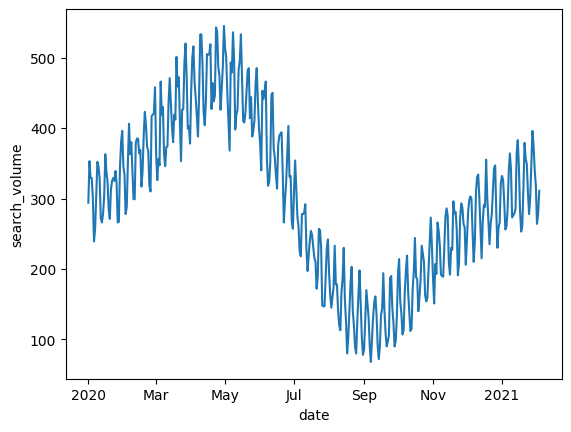

In [190]:
data.search_volume.plot.line(x='date', hue='geo');

In [191]:
def gen_model(data, priors=None, coords=None):
    
    if coords is None:
        coords = {key: value.values for key, value in data.coords.items()}
    
    default_priors = {
        "base_demand": pm_mrk.prior.Prior('Normal', mu=300, sigma=300),
        "weekly_demand_seasonality_order": 4,
        "yearly_demand_seasonality_order": 4,
        'weekly_demand_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=50, dims=('weekly_demand')),
        'yearly_demand_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=150, dims=('yearly_demand')),
        'base_impressions': pm_mrk.prior.Prior('Normal', mu=0, sigma=1),
        'weekly_imp_seasonality_order': 4,
        'yearly_imp_seasonality_order': 4,
        'weekly_imp_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('weekly_imp')),
        'yearly_imp_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('yearly_imp')),
        'base_clicks': pm_mrk.prior.Prior('Normal', mu=0, sigma=1),
        'weekly_click_seasonality_order': 4,
        'yearly_click_seasonality_order': 4,
        'weekly_click_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('weekly_click')),
        'yearly_click_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('yearly_click')),
    }
    
    if priors is None:
        priors = default_priors
    else:
        priors = {**default_priors, **priors}

    date = data['date']
    dayofyear = data['dayofyear']

    weekly_demand_seasonality = pm_mrk.mmm.WeeklyFourier(n_order=priors['weekly_demand_seasonality_order'], prefix='weekly_demand', priors=priors['weekly_demand_seasonality'])
    yearly_demand_seasonality = pm_mrk.mmm.YearlyFourier(n_order=priors['yearly_demand_seasonality_order'], prefix='yearly_demand', priors=priors['yearly_demand_seasonality'])
    weekly_imp_seasonality = pm_mrk.mmm.WeeklyFourier(n_order=priors['weekly_imp_seasonality_order'], prefix='weekly_imp', priors=priors['weekly_imp_seasonality'])
    yearly_imp_seasonality = pm_mrk.mmm.YearlyFourier(n_order=priors['yearly_imp_seasonality_order'], prefix='yearly_imp', priors=priors['yearly_imp_seasonality'])
    weekly_click_seasonality = pm_mrk.mmm.WeeklyFourier(n_order=priors['weekly_click_seasonality_order'], prefix='weekly_click', priors=priors['weekly_click_seasonality'])
    yearly_click_seasonality = pm_mrk.mmm.YearlyFourier(n_order=priors['yearly_click_seasonality_order'], prefix='yearly_click', priors=priors['yearly_click_seasonality'])

    with pm.Model(coords=coords) as model:
        dayofyear = pm.Data('dayofyear', dayofyear, dims=('date',))
        
        base_demand = priors['base_demand'].create_variable('base_demand')
        weekly_demand_seasonality = weekly_demand_seasonality.apply(dayofyear)
        yearly_demand_seasonality = yearly_demand_seasonality.apply(dayofyear)
        demand = pm.Deterministic("demand", pt.math.softplus(base_demand + weekly_demand_seasonality + yearly_demand_seasonality))

        obs_demand = pm.Poisson('obs_demand', mu=demand, dims=tuple(data.dims.keys()))

        base_impressions = priors['base_impressions'].create_variable('base_impressions')
        weekly_imp_seasonality = weekly_imp_seasonality.apply(dayofyear)
        yearly_imp_seasonality = yearly_imp_seasonality.apply(dayofyear)
        impressions_rate = pm.Deterministic("impressions_rate", pm.math.invlogit(base_impressions + weekly_imp_seasonality + yearly_imp_seasonality))

        impressions = pm.Binomial('impressions', n=obs_demand, p=impressions_rate, dims=tuple(data.dims.keys()))

        base_clicks = priors['base_clicks'].create_variable('base_clicks')
        weekly_click_seasonality = weekly_click_seasonality.apply(dayofyear)
        yearly_click_seasonality =  yearly_click_seasonality.apply(dayofyear)
        click_rate = pm.Deterministic("click_rate", pm.math.invlogit(base_clicks + weekly_click_seasonality + yearly_click_seasonality))

        clicks = pm.Binomial('clicks', n=impressions, p=click_rate, dims=tuple(data.dims.keys()))

    return model



In [192]:
def train_model(data, samples, priors=None, sampler_kwargs=None):
    
    if sampler_kwargs is None:
        sampler_kwargs = {}
    model = gen_model(data, priors)
    with pm.observe(model, {'obs_demand': data['search_volume'].values, 'impressions': data['impressions'].values, 'clicks': data['observed_clicks'].values}):
        trace = pm.sample(samples, **sampler_kwargs)
    return model, trace

In [233]:
train_test_split = 0.9
n_train = int(n_days * train_test_split)
train_data = data.sel(date=slice(None, date[n_train]))
test_data = data.sel(date=slice(date[n_train], None))

# train_data.loc[5:10, 'clicks'] = np.nan
# train_data.loc[15:20, 'impressions'] = np.nan
# train_data.loc[25:30, 'obs_demand'] = np.nan

model, trace = train_model(train_data, 1000, sampler_kwargs={'nuts_sampler': 'nutpie'})

/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:47: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  obs_demand = pm.Poisson('obs_demand', mu=demand, dims=tuple(data.dims.keys()))
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  impressions = pm.Binomial('impressions', n=obs_demand, p=impressions_rate, dims=tuple(data.dims.keys()))
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:61: FutureWarning: The return type of `Dataset.dims` will be changed to ret

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,63
,2000,0,0.11,319
,2000,0,0.10,63
,2000,0,0.10,31


In [234]:
def sample_posterior(model, trace, data=None):
    model_copy = pm.model.fgraph.clone_model(model)
    with model_copy:
        
        if data is not None:
            pm.set_data(
                {'dayofyear': data['dayofyear'].values}, coords={'date': data['date'].values})
            
        post_pred = pm.sample_posterior_predictive(trace)
    return post_pred


In [235]:
posterior_train = sample_posterior(model, trace)
posterior_test = sample_posterior(model, trace, data=test_data)

Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


In [236]:
posterior_train.posterior_predictive['clicks'].mean(dim=('chain', 'draw')).values.shape

(361,)

In [237]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

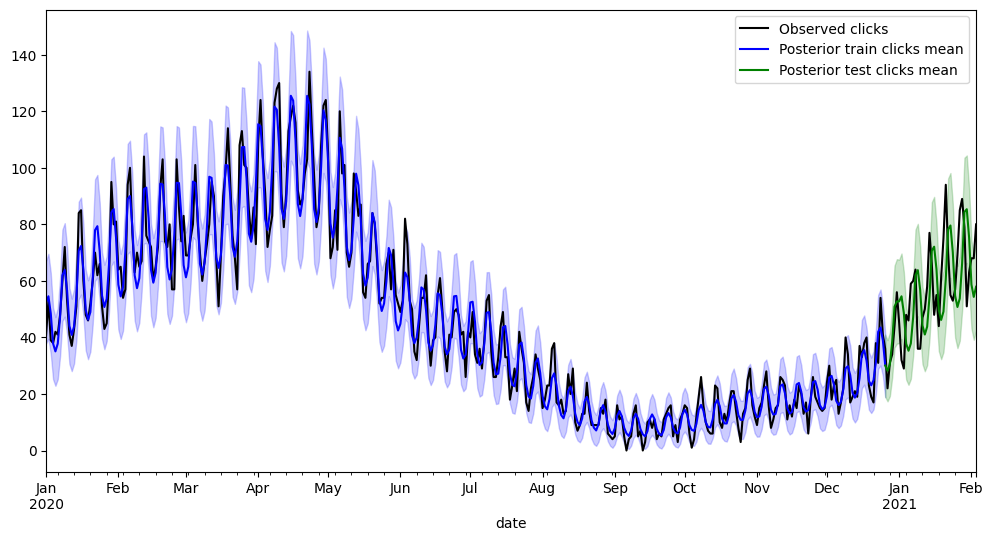

In [238]:
data_with_posterior = data.to_dataframe().reset_index().copy()
data_with_posterior['date'] = pd.to_datetime(data_with_posterior['date'])
data_with_posterior['posterior_train_clicks_mean'] = np.nan
data_with_posterior['posterior_train_clicks_std'] = np.nan
data_with_posterior.loc[:(n_train), 'posterior_train_clicks_mean'] = posterior_train.posterior_predictive['clicks'].mean(dim=('chain', 'draw')).values
data_with_posterior.loc[:(n_train), 'posterior_train_clicks_std'] = posterior_train.posterior_predictive['clicks'].std(dim=('chain', 'draw')).values
data_with_posterior['posterior_test_clicks_mean'] = np.nan
data_with_posterior['posterior_test_clicks_std'] = np.nan
data_with_posterior.loc[n_train:, 'posterior_test_clicks_mean'] = posterior_test.posterior_predictive['clicks'].mean(dim=('chain', 'draw')).values
data_with_posterior.loc[n_train:, 'posterior_test_clicks_std'] = posterior_test.posterior_predictive['clicks'].std(dim=('chain', 'draw')).values

fig, ax = plt.subplots(figsize=(12, 6))
data_with_posterior.plot(x='date', y='observed_clicks', ax=ax, label='Observed clicks', c='k')
data_with_posterior.plot(x='date', y='posterior_train_clicks_mean', ax=ax, label='Posterior train clicks mean', c='b')
data_with_posterior.plot(x='date', y='posterior_test_clicks_mean', ax=ax, label='Posterior test clicks mean', c='g')
plt.fill_between(
    data_with_posterior['date'].values, 
    data_with_posterior['posterior_train_clicks_mean'].values - 2 * data_with_posterior['posterior_train_clicks_std'].values, 
    data_with_posterior['posterior_train_clicks_mean'].values + 2 * data_with_posterior['posterior_train_clicks_std'].values, 
    alpha=0.2, color='b')
plt.fill_between(
    data_with_posterior['date'].values, 
    data_with_posterior['posterior_test_clicks_mean'].values - 2 * data_with_posterior['posterior_test_clicks_std'].values, 
    data_with_posterior['posterior_test_clicks_mean'].values + 2 * data_with_posterior['posterior_test_clicks_std'].values, 
    alpha=0.2, color='g')
plt.show()

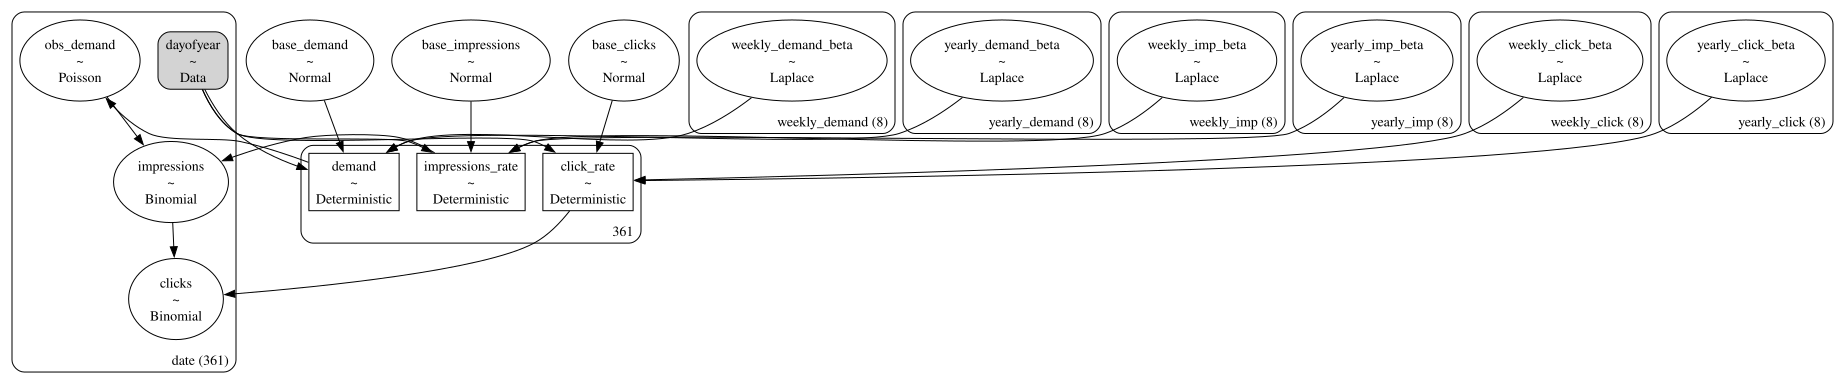

In [241]:
pm.model_to_graphviz(model)

In [240]:
with model:
    prior = pm.sample_prior_predictive()
    trace = pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [base_clicks, base_demand, base_impressions, clicks, impressions, obs_demand, weekly_click_beta, weekly_demand_beta, weekly_imp_beta, yearly_click_beta, yearly_demand_beta, yearly_imp_beta]
Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


Text(0.5, 1.0, 'Prior predictive draws for search volume')

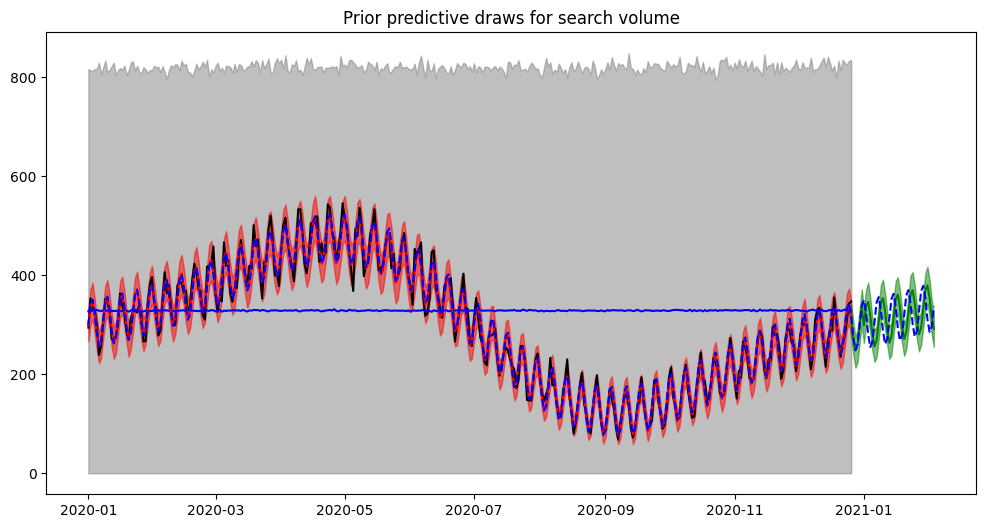

In [247]:
#prior.prior_predictive['search_volume']
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior['obs_demand'], hdi_prob=0.95)
date = train_data['date']
plt.fill_between(date, hdi_prior['obs_demand'].sel(hdi='lower'), hdi_prior['obs_demand'].sel(hdi='higher').values, color='gray', alpha=0.5)
plt.plot(date, train_data['search_volume'], color='black')
plt.plot(date, prior.prior['obs_demand'].mean(dim=('chain', 'draw')), color='blue')
plt.plot(date, trace.posterior_predictive['obs_demand'].mean(dim=('chain', 'draw')), color='red')
hdi_posterior = pm.hdi(trace.posterior_predictive['obs_demand'], hdi_prob=0.95)
plt.fill_between(date, hdi_posterior['obs_demand'].sel(hdi='lower'), hdi_posterior['obs_demand'].sel(hdi='higher'), color='red', alpha=0.5)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive['obs_demand'], hdi_prob=0.95)
plt.plot(hdi_posterior_new['date'], posterior_test.posterior_predictive['obs_demand'].mean(dim=('draw', 'chain')), color='green')
plt.fill_between(hdi_posterior_new['date'], hdi_posterior_new['obs_demand'].sel(hdi='lower'), hdi_posterior_new['obs_demand'].sel(hdi='higher'), color='green', alpha=0.5)
plt.plot(lam.date, lam, color='blue', linestyle='--')
plt.title("Prior predictive draws for search volume")

Text(0.5, 1.0, 'Prior predictive draws for search impressions')

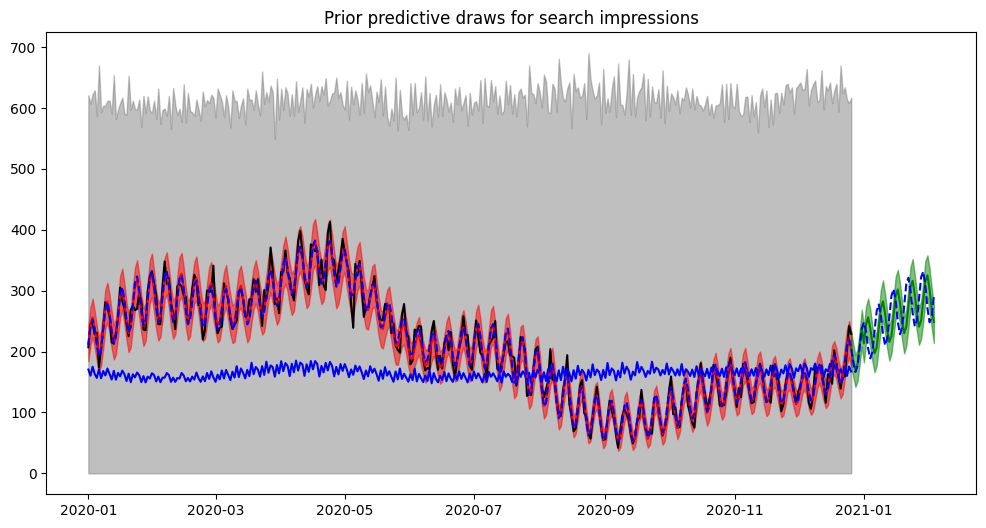

In [ ]:
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior['impressions'], hdi_prob=0.95)
plt.fill_between(date, hdi_prior['impressions'].sel(hdi='lower'), hdi_prior['impressions'].sel(hdi='higher').values, color='gray', alpha=0.5)
plt.plot(date, train_data['impressions'], color='black')
plt.plot(date, prior.prior['impressions'].mean(dim=('chain', 'draw')), color='blue')
plt.plot(date, trace.posterior_predictive['impressions'].mean(dim=('chain', 'draw')), color='red')
hdi_posterior = pm.hdi(trace.posterior_predictive['impressions'], hdi_prob=0.95)
plt.fill_between(date, hdi_posterior['impressions'].sel(hdi='lower'), hdi_posterior['impressions'].sel(hdi='higher'), color='red', alpha=0.5)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive['impressions'], hdi_prob=0.95)
plt.plot(hdi_posterior_new['date'], posterior_test.posterior_predictive['impressions'].mean(dim=('draw', 'chain')), color='green')
plt.fill_between(hdi_posterior_new['date'], hdi_posterior_new['impressions'].sel(hdi='lower'), hdi_posterior_new['impressions'].sel(hdi='higher'), color='green', alpha=0.5)
plt.plot(data['date'], impression_rate*lam, color='blue', linestyle='--')
plt.title("Prior Vs Posterior Predictive draws for search impressions")

Text(0.5, 1.0, 'Prior predictive draws for search clicks')

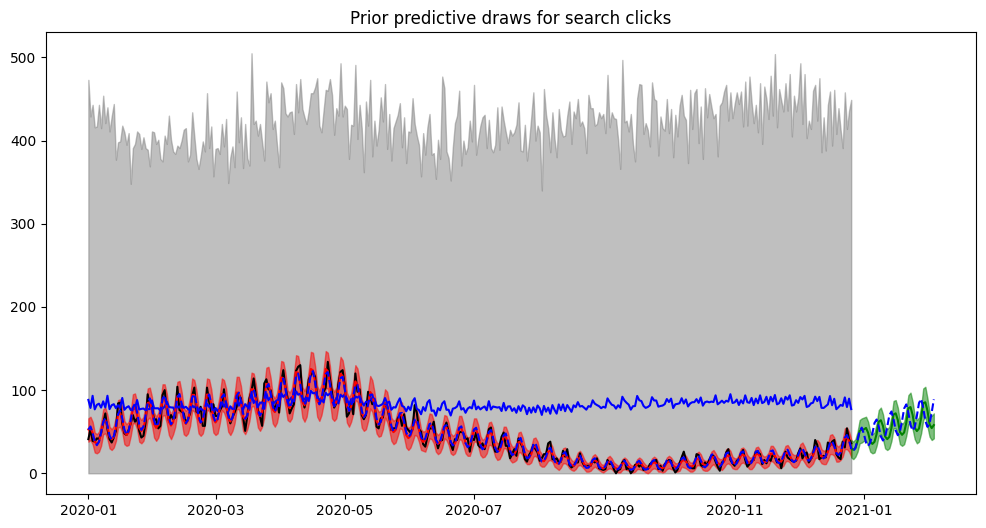

In [254]:
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior['clicks'], hdi_prob=0.95)
plt.fill_between(date, hdi_prior['clicks'].sel(hdi='lower'), hdi_prior['clicks'].sel(hdi='higher').values, color='gray', alpha=0.5)
plt.plot(date, train_data['observed_clicks'], color='black')
plt.plot(date, prior.prior['clicks'].mean(dim=('chain', 'draw')), color='blue')
plt.plot(date, trace.posterior_predictive['clicks'].mean(dim=('chain', 'draw')), color='red')
hdi_posterior = pm.hdi(trace.posterior_predictive['clicks'], hdi_prob=0.95)
plt.fill_between(date, hdi_posterior['clicks'].sel(hdi='lower'), hdi_posterior['clicks'].sel(hdi='higher'), color='red', alpha=0.5)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive['clicks'], hdi_prob=0.95)
plt.plot(hdi_posterior_new['date'], posterior_test.posterior_predictive['clicks'].mean(dim=('draw', 'chain')), color='green')
plt.fill_between(hdi_posterior_new['date'], hdi_posterior_new['clicks'].sel(hdi='lower'), hdi_posterior_new['clicks'].sel(hdi='higher'), color='green', alpha=0.5)
plt.plot(data['date'], impression_rate*lam*click_rate, color='blue', linestyle='--')
plt.title("Prior predictive draws for search clicks")